# Flight Delay Prediction Using Classification Techniques

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(50000, 31)
   YEAR  MONTH  DAY  DAY_OF_WEEK AIRLINE  FLIGHT_NUMBER TAIL_NUMBER  \
0  2015      1    1            4      AS             98      N407AS   
1  2015      1    1            4      AA           2336      N3KUAA   
2  2015      1    1            4      US            840      N171US   
3  2015      1    1            4      AA            258      N3HYAA   
4  2015      1    1            4      AS            135      N527AS   

  ORIGIN_AIRPORT DESTINATION_AIRPORT  SCHEDULED_DEPARTURE  ...  ARRIVAL_TIME  \
0            ANC                 SEA                    5  ...         408.0   
1            LAX                 PBI                   10  ...         741.0   
2            SFO                 CLT                   20  ...         811.0   
3            LAX                 MIA                   20  ...         756.0   
4            SEA                 ANC                   25  ...         259.0   

   ARRIVAL_DELAY  DIVERTED  CANCELLED  CANCELLATION_REASON  AIR_SYSTEM_DELAY  \


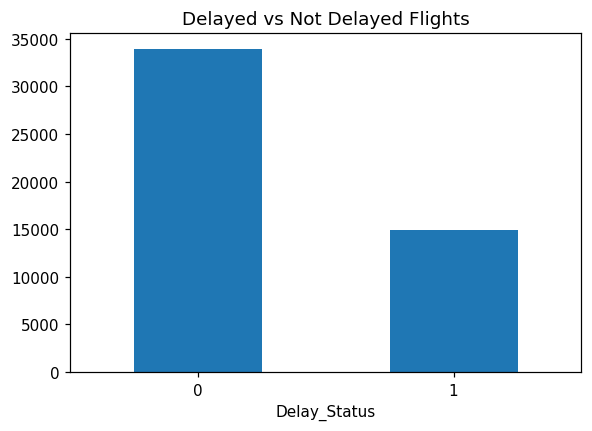

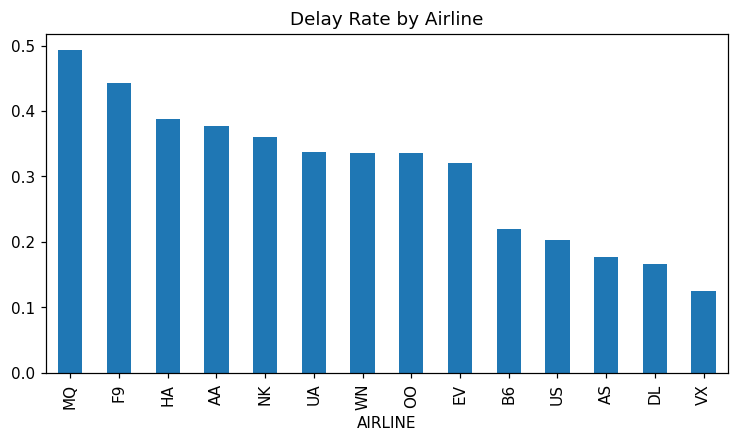

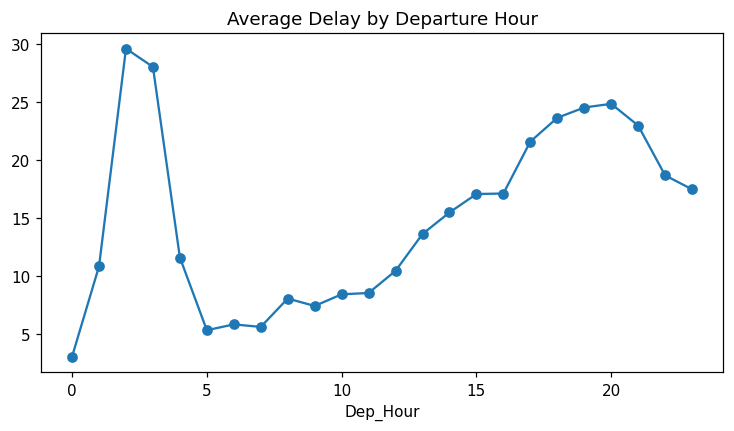

Logistic Regression Accuracy: 0.7829966157317199
[[6587  198]
 [1918 1048]]
Decision Tree Accuracy: 0.8305814788226848
[[5956  829]
 [ 823 2143]]


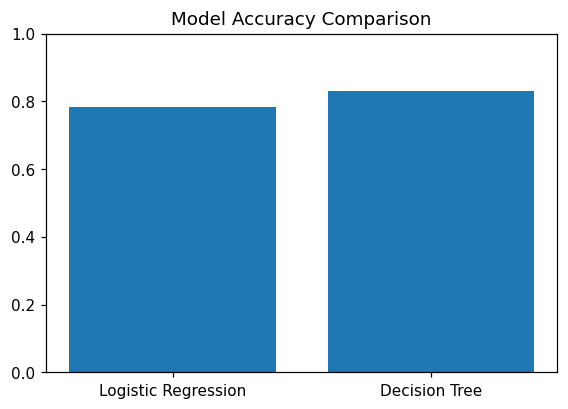

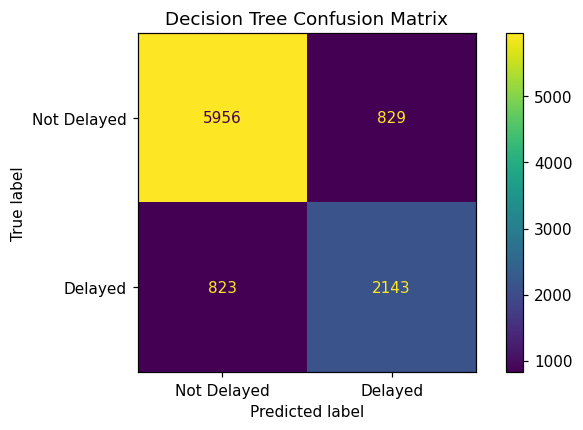

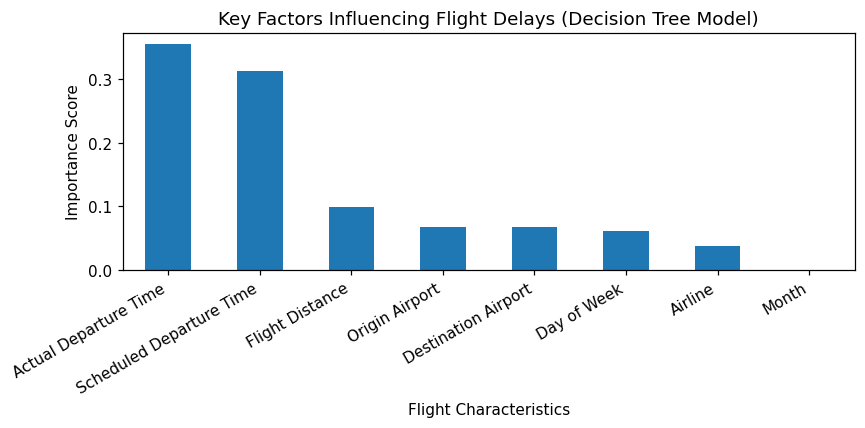

In [38]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


# load dataset (make sure path is correct)
df_raw = pd.read_csv("/content/drive/MyDrive/flights.csv", nrows=50000)

print(df_raw.shape)
print(df_raw.head())


# keep only useful columns for this task
df = df_raw[
    [
        'MONTH',
        'DAY_OF_WEEK',
        'AIRLINE',
        'ORIGIN_AIRPORT',
        'DESTINATION_AIRPORT',
        'SCHEDULED_DEPARTURE',
        'DEPARTURE_TIME',
        'DISTANCE',
        'ARRIVAL_DELAY',
        'CANCELLED'
    ]
].copy()


# remove cancelled flights (no arrival delay for those)
df = df[df['CANCELLED'] == 0]

# remove missing values
df = df.dropna()

print("after cleaning:", df.shape)


# create target column (1 = delayed, 0 = not delayed)
df['Delay_Status'] = np.where(df['ARRIVAL_DELAY'] > 15, 1, 0)

print(df['Delay_Status'].value_counts())


# quick look at class balance
plt.figure(figsize=(6,4))
df['Delay_Status'].value_counts().sort_index().plot(kind='bar')
plt.title("Delayed vs Not Delayed Flights")
plt.xticks(rotation=0)
plt.show()


# check delay by airline (just for insight)
airline_delay_rate = df.groupby('AIRLINE')['Delay_Status'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,4))
airline_delay_rate.plot(kind='bar')
plt.title("Delay Rate by Airline")
plt.show()


# check delay vs departure hour
df['Dep_Hour'] = (df['SCHEDULED_DEPARTURE'] // 100).astype(int)

avg_delay_by_hour = df.groupby('Dep_Hour')['ARRIVAL_DELAY'].mean()

plt.figure(figsize=(8,4))
avg_delay_by_hour.plot(kind='line', marker='o')
plt.title("Average Delay by Departure Hour")
plt.show()


# drop columns not needed for model
model_df = df.drop(['ARRIVAL_DELAY', 'CANCELLED', 'Dep_Hour'], axis=1).copy()


# encode categorical variables
le_airline = LabelEncoder()
le_origin = LabelEncoder()
le_dest = LabelEncoder()

model_df['AIRLINE'] = le_airline.fit_transform(model_df['AIRLINE'])
model_df['ORIGIN_AIRPORT'] = le_origin.fit_transform(model_df['ORIGIN_AIRPORT'])
model_df['DESTINATION_AIRPORT'] = le_dest.fit_transform(model_df['DESTINATION_AIRPORT'])


# split features and target
X = model_df.drop('Delay_Status', axis=1)
y = model_df['Delay_Status']


# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# scaling (mainly for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# logistic regression model
lr_model = LogisticRegression(max_iter=500)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))


# decision tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))


# compare both models
lr_acc = accuracy_score(y_test, y_pred_lr)
dt_acc = accuracy_score(y_test, y_pred_dt)

plt.figure(figsize=(6,4))
plt.bar(['Logistic Regression', 'Decision Tree'], [lr_acc, dt_acc])
plt.title("Model Accuracy Comparison")
plt.ylim(0,1)
plt.show()


# confusion matrix for decision tree
cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Delayed", "Delayed"])
disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()


# feature importance from decision tree
importance = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False)

# rename features (optional but better)
importance.index = [
    "Actual Departure Time",
    "Scheduled Departure Time",
    "Flight Distance",
    "Origin Airport",
    "Destination Airport",
    "Day of Week",
    "Airline",
    "Month"
]

# plot
plt.figure(figsize=(8,4))
importance.plot(kind='bar')

plt.title("Key Factors Influencing Flight Delays (Decision Tree Model)")
plt.xlabel("Flight Characteristics")
plt.ylabel("Importance Score")

plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()